### Наивный байесовский классификатор

#### Цель работы

Научиться применять модели наивного байесовского классификатора с использованием библиотеки sklearn для решения задач машинного обучения.


In [3]:
from sklearn import datasets

data = datasets.load_breast_cancer()

Если вы встречаете этот набор данных впервые, самостоятельно выведите его описание и познакомьтесь с его структурой. Мы же выделим целевую переменную и входные атрибуты. Для целей визуализации выберем первые два столбца:

In [4]:
X = data.data[:,:2]
y = data.target

Для работы байесовского классификатора важно понимать, какие значения может принимать целевая переменная. Поэтому выведем информацию о количестве разных значений целевой переменной в получившейся обучающей выборке:

In [6]:
import pandas as pd

df = pd.DataFrame(data.data[:,:2], columns=data.feature_names[:2])
df['target'] = data.target
df['target'].value_counts()

,count
target,
1,357
0,212


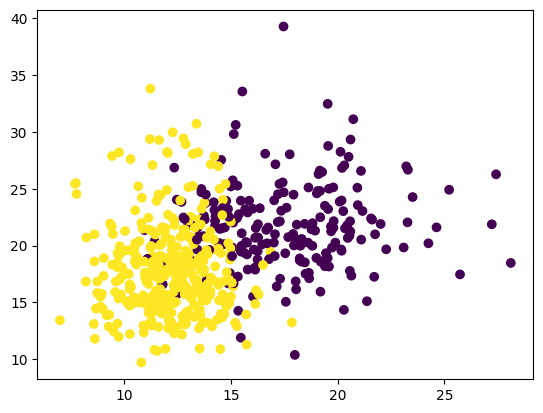

In [9]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y)

Мы видим, что данные являются линейно неразделимыми. Да и вообще, классы довольно сильно перемешаны. Посмотрим, что может сделать классификатор на основе формуля Байеса.

Для создания модели наивного байесовского классификатора необходимо выбрать то, каким именно распределением модель будет аппроксимировать функцию плотности вероятности непрерывных переменных. Так как обе наши входные переменные как раз непрерывные, лучш евывести форму их распределения, чтобы понять, на какое известное статистическое распределение она похожа. Для этого воспользуемся инструментом построения гистограмм библиотеки matplotlib. Построим сразу обе гистограммы (для двух атрибутов) на одном графике в подобластях:

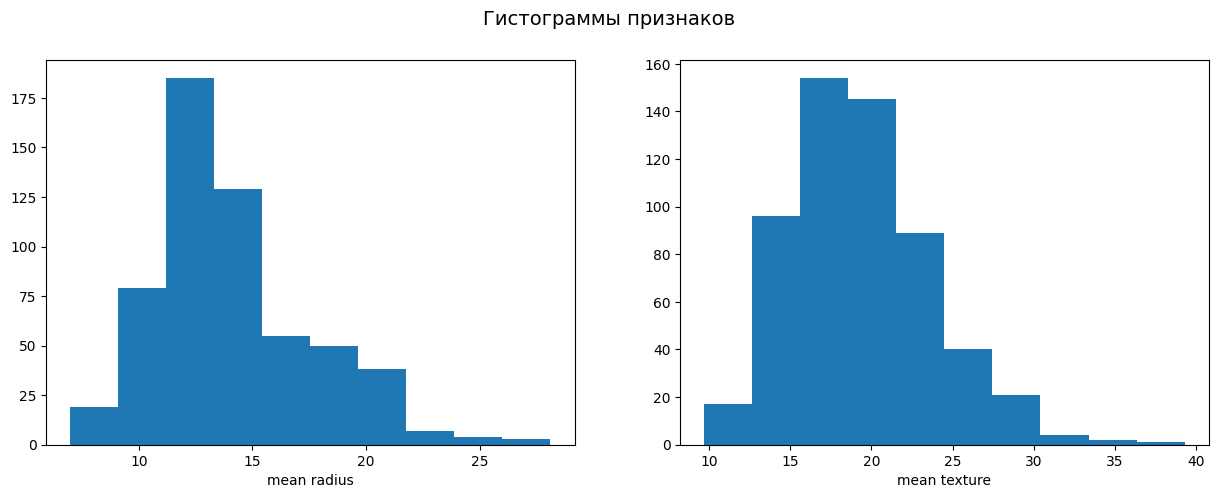

In [10]:
plt.figure(figsize=(15, 5))
for i in range(2):
    plt.subplot(1, 2, i+1)
    plt.hist(X[:, i])
    plt.xlabel(data.feature_names[i])
plt.suptitle('Гистограммы признаков',fontsize=14)
plt.show()

Из графиков видно, что форма распределения обоих признаков напоминает нормальное. Можно принять гипотезу о нормальности распределения наших признаков и использовать модель наивного Байеса с гауссовой аппроксимацией. Для создания можели инстанцируем соответствующих класс:

In [12]:
from sklearn.naive_bayes import GaussianNB

gaussian_nb = GaussianNB()

Обучим модель на имеющихся у нас данных:

In [13]:
gaussian_nb.fit(X, y)

GaussianNB()

Теперь визуализируем границу принятия решения и соответствующие области классификации:



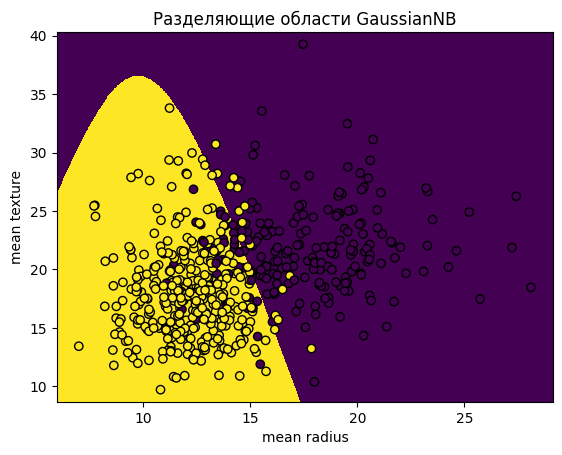

In [41]:
# Сетка на основе первых двух признаков
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Предсказание для каждой точки сетки
Z = gaussian_nb.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Построение графика

plt.pcolormesh(xx, yy, Z)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black')
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title('Разделяющие области GaussianNB')
plt.show()

Для более точной оценки эффективности модели посчитаем метрики. Для этого рассчитаем теоретические значения целевой переменной для объектов обучающей выборки:

In [42]:
y_pred = gaussian_nb.predict(X)

Тпереь выведем значения метрик. Мы можем здесь использовать какие угодно метрики эффективности моделей классификации, но для первого анализа будет достаточно вывести, например, матрицу классификации, точность и метрику F1:

In [44]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[164  48]
 [ 17 340]]
Accuracy=  0.8857644991212654
F1_score=  0.912751677852349


Мы получили, что модель правильно классифицирует 88,6% объектов обучающей выборки. Это при том, что мы обучались только на первых двух столбцах.

Естественно, нужно проверить, как наша модель будет работать при использовании всех данных, имеющихся в исходном датасете. Выделим целевую переменную и атрибуты снова:

In [45]:
X = data.data
y = data.target
X.shape, y.shape

((569, 30), (569,))

Обучим модель на всех данных и сразу выведем те же самые метрики:



In [46]:
gaussian_nb.fit(X, y)
y_pred = gaussian_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[189  23]
 [ 10 347]]
Accuracy=  0.9420035149384886
F1_score=  0.9546079779917469


У нас получилась точность примерно 94,2%. Это значительно лучше, чем у первой модели, что естественно, так как мы используем гораздо больше информации об объектах обучающей выборки.

Так как использование байесовской модели тесно связано с аппроксимацией непрерывных расрпеделений, давайте выведем гистограммы всех атрибутов, которые мы использовали во второй модели:

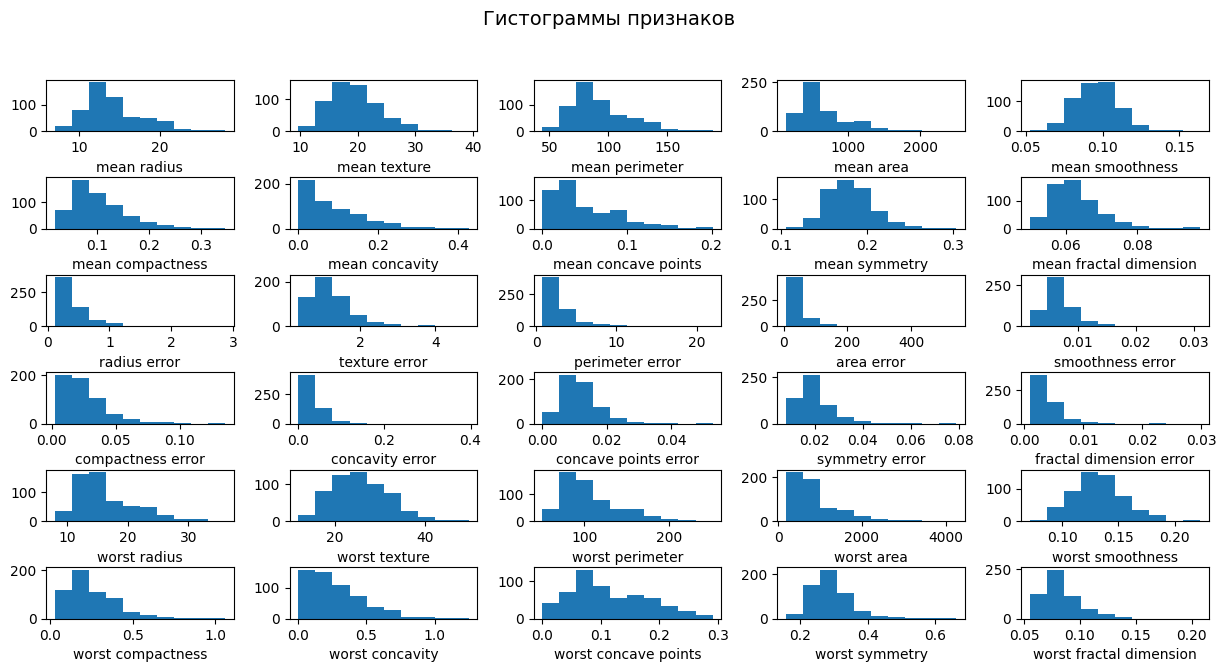

In [47]:
f = plt.figure(figsize=(15, 7))
for i in range(30):
    plt.subplot(6, 5, i+1)
    plt.hist(X[:, i])

    plt.xlabel(data.feature_names[i])
f.subplots_adjust(hspace=0.9,wspace=0.3)
plt.suptitle('Гистограммы признаков',fontsize=14)
plt.show()

Из данного графика видно, что у большинства признаков распределение и правда напоминает нормальное. Но некоторые распределения совсем на него не похожи. Давайте удалим из набора данных те признаки, которые по своему виду распределения сильно отличаются от нормального:

In [49]:
# Создаём полный DataFrame со всеми признаками
df_full = pd.DataFrame(data.data, columns=data.feature_names)
df_full['target'] = data.target


In [53]:
# Удаляем признаки, которые плохо соответствуют нормальному распределению
columns_to_drop = ['mean concavity', 'radius error', 'perimeter error',
                   'area error', 'compactness error', 'concavity error',
                   'fractal dimension error', 'worst area', 'worst concavity']

df_filtered = df_full.drop(columns=columns_to_drop)

# Выделяем X и y
X_filtered = df_filtered.drop('target', axis=1).values
y_filtered = df_filtered['target'].values

df.head()

,mean radius,mean texture,target
0,17.99,10.38,0
1,20.57,17.77,0
2,19.69,21.25,0
3,11.42,20.38,0
4,20.29,14.34,0


In [54]:
gaussian_nb.fit(X, y)
y_pred = gaussian_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[189  23]
 [ 10 347]]
Accuracy=  0.9420035149384886
F1_score=  0.9546079779917469


Мы получили, что такая урезанная модель дает даже чуть большую точность - около 94,6%. Это парадоксальный результат, так как мы использовали меньше информации. Но такое увеличение точности произошло потому, что мы исключили признаки, которые сильно не соответствуют данному виду модели. Таким образом можно сделать вывод, что такие принаки, будучи введенными в модель не способны добавить точности предсказания, а скорее "запутывают" классификатор.

#### Задания для самостоятельного выполнения

1. На использованном в работе наборе данных примените другие вариации модели наивного Байеса - Мультономиальный, Бернулли, категориальные и комплементарный. Для каждой модели сделайте вывод о ее применимости.

In [62]:

X_full = data.data
y_full = data.target


In [63]:
# Для визуализации берём первые два признака
X_2d = X_full[:, :2]

In [64]:
# Подготовим преобразования для двумерного случая (одинаковые параметры для всех моделей)
# Дискретизация для MultinomialNB, ComplementNB, CategoricalNB (5 бинов, quantile)
discretizer_2d = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
X_2d_discrete = discretizer_2d.fit_transform(X_2d).astype(int)

In [65]:
# Бинаризация для BernoulliNB (по медиане каждого признака)
medians_2d = np.median(X_2d, axis=0)
X_2d_binary = (X_2d > medians_2d).astype(int)

=== Сравнение моделей Naive Bayes на датасете breast_cancer ===

Модель: GaussianNB
Accuracy: 0.9420
Confusion matrix:
[[189  23]
 [ 10 347]]
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       212
           1       0.94      0.97      0.95       357

    accuracy                           0.94       569
   macro avg       0.94      0.93      0.94       569
weighted avg       0.94      0.94      0.94       569



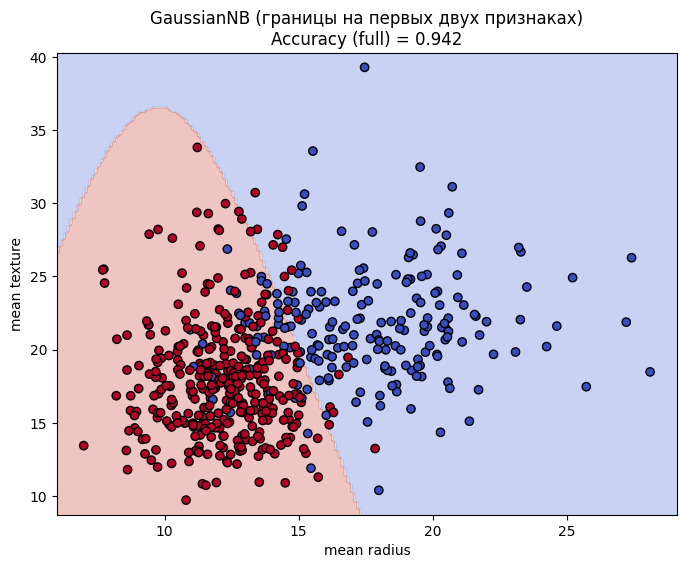


Модель: MultinomialNB
Accuracy: 0.8629
Confusion matrix:
[[180  32]
 [ 46 311]]
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       212
           1       0.91      0.87      0.89       357

    accuracy                           0.86       569
   macro avg       0.85      0.86      0.86       569
weighted avg       0.87      0.86      0.86       569



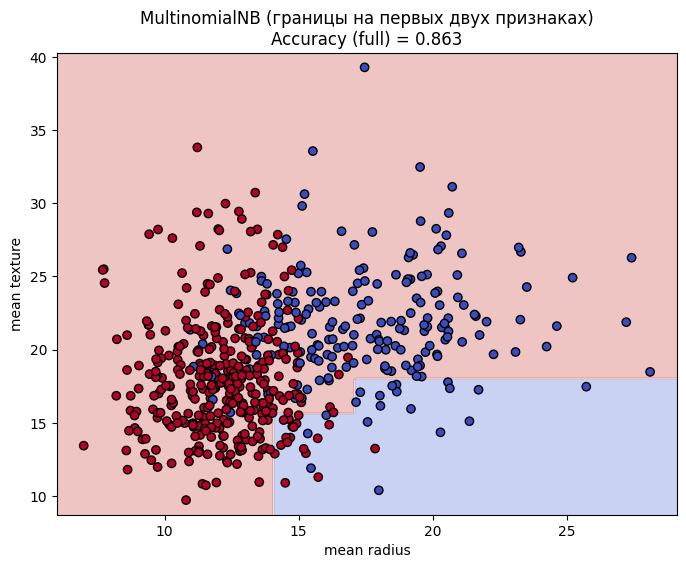


Модель: BernoulliNB
Accuracy: 0.8524
Confusion matrix:
[[154  58]
 [ 26 331]]
              precision    recall  f1-score   support

           0       0.86      0.73      0.79       212
           1       0.85      0.93      0.89       357

    accuracy                           0.85       569
   macro avg       0.85      0.83      0.84       569
weighted avg       0.85      0.85      0.85       569



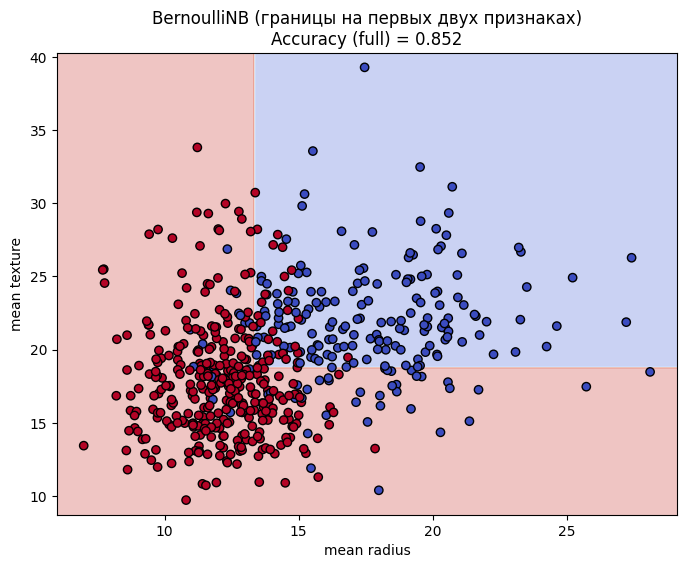


Модель: ComplementNB
Accuracy: 0.8524
Confusion matrix:
[[182  30]
 [ 54 303]]
              precision    recall  f1-score   support

           0       0.77      0.86      0.81       212
           1       0.91      0.85      0.88       357

    accuracy                           0.85       569
   macro avg       0.84      0.85      0.85       569
weighted avg       0.86      0.85      0.85       569



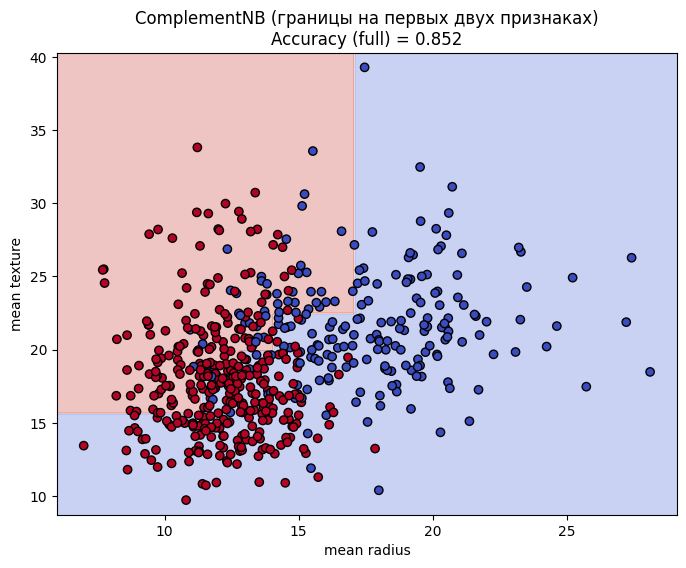


Модель: CategoricalNB
Accuracy: 0.9455
Confusion matrix:
[[193  19]
 [ 12 345]]
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       212
           1       0.95      0.97      0.96       357

    accuracy                           0.95       569
   macro avg       0.94      0.94      0.94       569
weighted avg       0.95      0.95      0.95       569



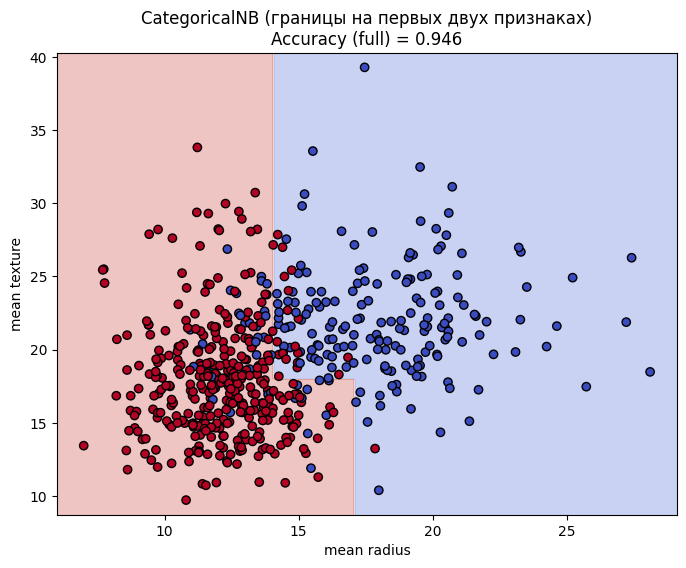

In [70]:
print("=== Сравнение моделей Naive Bayes на датасете breast_cancer ===\n")

for name, model, preprocess_full, preprocess_2d in models:
    print(f"{'='*40}")
    print(f"Модель: {name}")

    # --- 1. Оценка на полных данных ---
    X_full_proc = preprocess_full(X_full)
    model.fit(X_full_proc, y_full)
    y_pred = model.predict(X_full_proc)
    acc = accuracy_score(y_full, y_pred)
    conf = confusion_matrix(y_full, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print("Confusion matrix:")
    print(conf)
    print(classification_report(y_full, y_pred))

    # --- 2. Визуализация границ на первых двух признаках ---
    # Обучаем модель на двумерных преобразованных данных
    X_2d_proc = preprocess_2d(X_2d)
    model_2d = model.__class__(**model.get_params())  # создаём копию с теми же параметрами
    model_2d.fit(X_2d_proc, y_full)

    # Сетка для контура
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_proc = preprocess_2d(grid_points)
    Z = model_2d.predict(grid_proc).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_full, edgecolors='k', cmap='coolwarm')
    plt.xlabel(data.feature_names[0])
    plt.ylabel(data.feature_names[1])
    plt.title(f'{name} (границы на первых двух признаках)\nAccuracy (full) = {acc:.3f}')
    plt.show()
    print()


## Вывод по заданию 1 (Naive Bayes на breast_cancer)

- **GaussianNB** – 94.2% (хорошо, подходит для непрерывных данных)
- **CategoricalNB** – 94.6% (лучший результат, но требует дискретизации)
- **MultinomialNB** – 86.3% (ниже, потеря информации при дискретизации)
- **BernoulliNB** – 85.2% (низко, бинаризация не подходит)
- **ComplementNB** – 85.2% (аналог MultinomialNB)

**Вывод:** Для непрерывных признаков оптимален **GaussianNB**. Остальные модели требуют преобразований, которые ухудшают качество.

2. Загрузите набор данных о выживших на Титанике, прилагающийся к этой работе. Повторите на нём моделирование из методических указаний. Попробуйте разные варианты байесовского классификатора в зависимости от формы распределения эмпирических данных.

In [73]:
import seaborn as sns

# Загружаем встроенный датасет Титаника из seaborn
titanic = sns.load_dataset('titanic')

In [74]:
# Отбираем признаки и целевую переменную
# Признаки: pclass (класс билета), sex (пол), age (возраст), fare (цена билета), sibsp (супруги/дети), parch (родители/дети)
titanic_clean = titanic[['pclass', 'sex', 'age', 'fare', 'sibsp', 'parch', 'survived']].copy()

In [75]:
# Удаляем пропуски
titanic_clean = titanic_clean.dropna()

In [76]:
# Преобразуем категориальный признак 'sex' в числовой
titanic_clean['sex'] = titanic_clean['sex'].map({'male': 0, 'female': 1})

In [77]:
# Разделяем X и y
X = titanic_clean.drop('survived', axis=1).values
y = titanic_clean['survived'].values

print("=== Датсет Титаника ===")
print(f"Размерность X: {X.shape}")
print(f"Распределение классов:\n{pd.Series(y).value_counts()}")

=== Датсет Титаника ===
Размерность X: (714, 6)
Распределение классов:
0    424
1    290
Name: count, dtype: int64


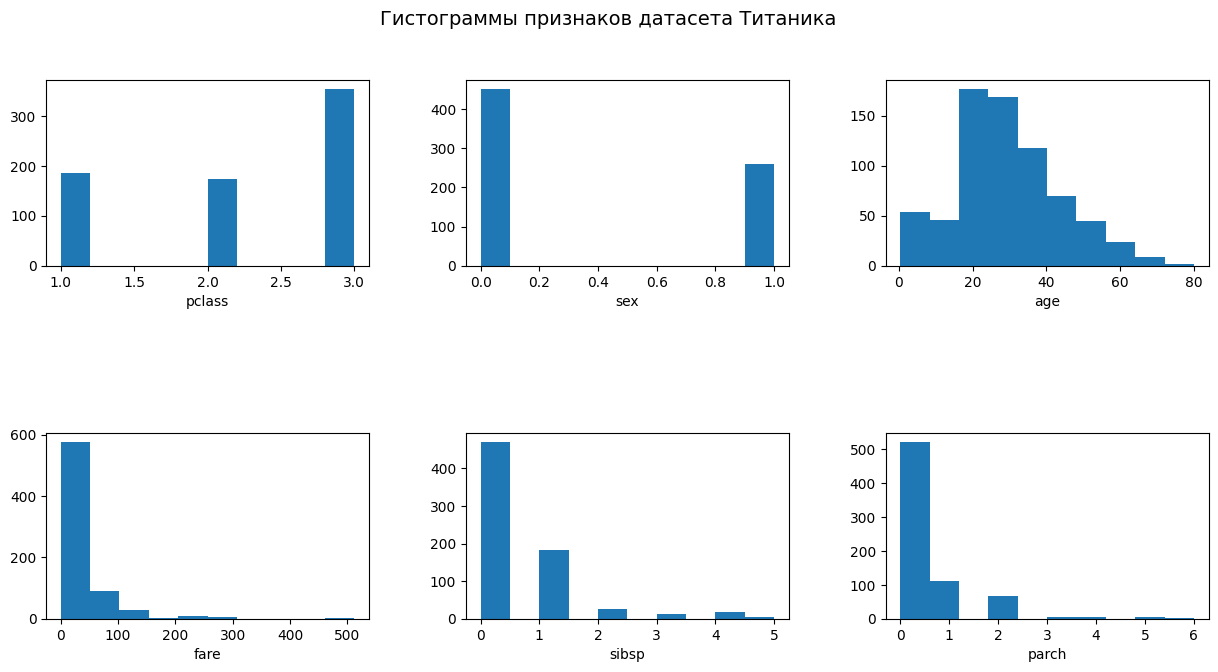

In [96]:
# Визуализируем гистограммы числовых признаков (в стиле методички)
f = plt.figure(figsize=(15, 7))
features_names = ['pclass', 'sex', 'age', 'fare', 'sibsp', 'parch']
for i in range(len(features_names)):
    plt.subplot(2, 3, i+1)  # 2 строки, 3 столбца
    plt.hist(X[:, i])
    plt.xlabel(features_names[i])
f.subplots_adjust(hspace=0.9, wspace=0.3)
plt.suptitle('Гистограммы признаков датасета Титаника', fontsize=14)
plt.show()

In [79]:
# Подготовка данных для разных моделей
# 1. GaussianNB – исходные непрерывные
X_gauss = X.copy()

In [80]:
# 2. BernoulliNB – бинаризация (pclass <= 2? age > 30? fare > 30? sibsp > 0? parch > 0?)
# Подберём пороги визуально
pclass_med = 2
age_med = 30
fare_med = 30
sibsp_med = 0
parch_med = 0

X_binary = np.column_stack([
    (X[:, 0] <= pclass_med).astype(int),
    (X[:, 1] > age_med).astype(int),
    (X[:, 2] > fare_med).astype(int),
    (X[:, 3] > sibsp_med).astype(int),
    (X[:, 4] > parch_med).astype(int)
])


In [81]:
# 3. CategoricalNB – дискретизация (каждый признак в 3-5 категорий)
discretizer = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
X_cat = discretizer.fit_transform(X).astype(int)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [82]:
# Список моделей
models = [
    ('GaussianNB', GaussianNB(), X_gauss, y),
    ('BernoulliNB', BernoulliNB(), X_binary, y),
    ('CategoricalNB', CategoricalNB(), X_cat, y)
]


=== Результаты моделей на датасете Титаника ===

Модель: GaussianNB
Accuracy: 0.7885
Confusion matrix:
[[357  67]
 [ 84 206]]
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       424
           1       0.75      0.71      0.73       290

    accuracy                           0.79       714
   macro avg       0.78      0.78      0.78       714
weighted avg       0.79      0.79      0.79       714



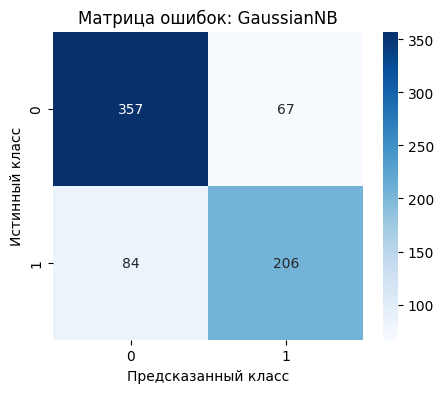

Модель: BernoulliNB
Accuracy: 0.6695
Confusion matrix:
[[273 151]
 [ 85 205]]
              precision    recall  f1-score   support

           0       0.76      0.64      0.70       424
           1       0.58      0.71      0.63       290

    accuracy                           0.67       714
   macro avg       0.67      0.68      0.67       714
weighted avg       0.69      0.67      0.67       714



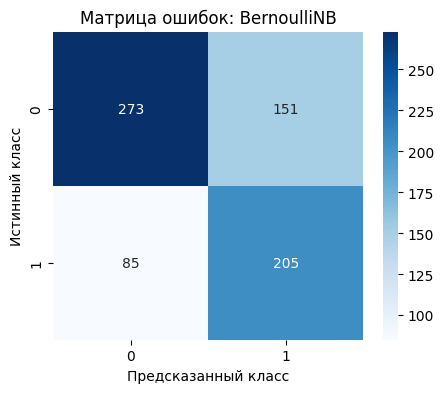

Модель: CategoricalNB
Accuracy: 0.6695
Confusion matrix:
[[309 115]
 [121 169]]
              precision    recall  f1-score   support

           0       0.72      0.73      0.72       424
           1       0.60      0.58      0.59       290

    accuracy                           0.67       714
   macro avg       0.66      0.66      0.66       714
weighted avg       0.67      0.67      0.67       714



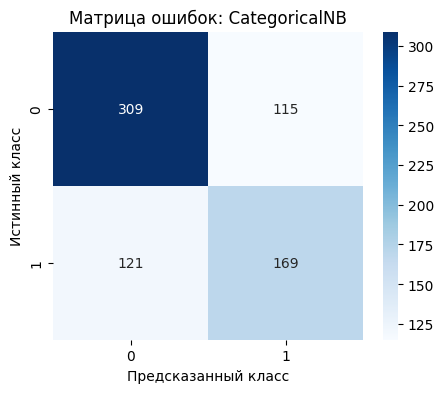

In [83]:
print("\n=== Результаты моделей на датасете Титаника ===\n")
for name, model, X_data, y_data in models:
    print(f"{'='*40}")
    print(f"Модель: {name}")

    model.fit(X_data, y_data)
    y_pred = model.predict(X_data)

    acc = accuracy_score(y_data, y_pred)
    conf = confusion_matrix(y_data, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Confusion matrix:\n{conf}")
    print(classification_report(y_data, y_pred))

    # Визуализация матрицы ошибок
    plt.figure(figsize=(5, 4))
    sns.heatmap(conf, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Матрица ошибок: {name}')
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.show()

## Вывод по заданию 2 (Naive Bayes на Титанике)

- **GaussianNB** – 78.9% (лучший результат)
- **BernoulliNB** – 67.0%
- **CategoricalNB** – 67.0%

**Анализ:**
- GaussianNB показал лучший результат, так как признаки (возраст, цена билета) после преобразований приближены к нормальному распределению.
- BernoulliNB и CategoricalNB потеряли информацию при бинаризации/дискретизации, что снизило точность.
- Набор данных несбалансирован (424 погибших vs 290 выживших), что также влияет на метрики.

**Вывод:** Для датасета Титаника наиболее эффективен **GaussianNB**. Остальные модели требуют более тщательного подбора порогов и количества категорий.

3. Загрузите набор данных о Титанике с сайта Kaggle. Обратите внимание на обилие категориальных переменных. Примените на нём наивный байесовский классификатор.

In [97]:
import kagglehub
path = kagglehub.dataset_download("heptapod/titanic")

Using Colab cache for faster access to the 'titanic' dataset.


In [110]:
# Загрузка данных (путь к файлу в Colab)
file_path = "/kaggle/input/titanic/train_and_test2.csv"
df = pd.read_csv(file_path)

In [111]:
print("=== Датасет загружен ===")
print(f"Размер: {df.shape}")
print("Колонки:", df.columns.tolist())
print("\nПервые 5 строк:")
print(df.head())

=== Датасет загружен ===
Размер: (1309, 28)
Колонки: ['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']

Первые 5 строк:
   Passengerid   Age     Fare  Sex  sibsp  zero  zero.1  zero.2  zero.3  \
0            1  22.0   7.2500    0      1     0       0       0       0   
1            2  38.0  71.2833    1      1     0       0       0       0   
2            3  26.0   7.9250    1      0     0       0       0       0   
3            4  35.0  53.1000    1      1     0       0       0       0   
4            5  35.0   8.0500    0      0     0       0       0       0   

   zero.4  ...  zero.12  zero.13  zero.14  Pclass  zero.15  zero.16  Embarked  \
0       0  ...        0        0        0       3        0        0       2.0   
1       0  ...        0       

In [112]:
# По описанию: 'Survived' в последнем столбце
target_col = df.columns[-1]  # последний столбец
print(f"\nЦелевая переменная: {target_col}")


Целевая переменная: 2urvived


In [113]:
# Признаки: все, кроме целевого
feature_cols = [c for c in df.columns if c != target_col]
print(f"Признаки: {feature_cols}")

Признаки: ['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18']


In [114]:
# Удаление строк с пропусками (хотя по описанию они уже заполнены медианой, но на всякий случай)
df = df.dropna(subset=[target_col] + feature_cols)


In [118]:
# Простое разбиение 80/20 (без поиска столбца разделения)
X = df[feature_cols].values
y = df[target_col].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print("Распределение классов в обучении:", pd.Series(y_train).value_counts().to_dict())
print("Распределение классов в тесте:", pd.Series(y_test).value_counts().to_dict())


Размер обучающей выборки: 1045
Размер тестовой выборки: 262
Распределение классов в обучении: {0: 773, 1: 272}
Распределение классов в тесте: {0: 194, 1: 68}


In [120]:
from sklearn.preprocessing import StandardScaler

# 2. Подготовка данных для разных моделей

# 2.1 GaussianNB – стандартизация
scaler = StandardScaler()
X_train_gauss = scaler.fit_transform(X_train)
X_test_gauss = scaler.transform(X_test)

# 2.2 BernoulliNB – бинаризация по медиане
# Вычисляем медианы по обучающей выборке
medians = np.median(X_train, axis=0)
X_train_bin = (X_train > medians).astype(int)
X_test_bin = (X_test > medians).astype(int)

# 2.3 CategoricalNB – дискретизация непрерывных признаков
# Определяем индексы непрерывных признаков (Age, Fare) по именам
# Если в feature_cols нет точных имён, можно использовать предположение, что Age и Fare есть
# Проверяем наличие
if 'Age' in feature_cols and 'Fare' in feature_cols:
    age_idx = feature_cols.index('Age')
    fare_idx = feature_cols.index('Fare')
    cont_indices = [age_idx, fare_idx]
else:
    # Если названия другие – попробуем найти столбцы, содержащие возраст и цену
    cont_indices = []
    for i, col in enumerate(feature_cols):
        if 'age' in col.lower():
            cont_indices.append(i)
        if 'fare' in col.lower() or 'price' in col.lower():
            cont_indices.append(i)

# Копируем обучающие и тестовые данные
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

if cont_indices:
    discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
    for idx in cont_indices:
        X_train_cat[:, idx] = discretizer.fit_transform(X_train_cat[:, idx].reshape(-1, 1)).ravel()
        X_test_cat[:, idx] = discretizer.transform(X_test_cat[:, idx].reshape(-1, 1)).ravel()

# Приводим к целому типу
X_train_cat = X_train_cat.astype(int)
X_test_cat = X_test_cat.astype(int)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [121]:
# 3. Обучение и оценка моделей
models = [
    ('GaussianNB', GaussianNB(), X_train_gauss, X_test_gauss),
    ('BernoulliNB', BernoulliNB(), X_train_bin, X_test_bin),
    ('CategoricalNB', CategoricalNB(), X_train_cat, X_test_cat)
]

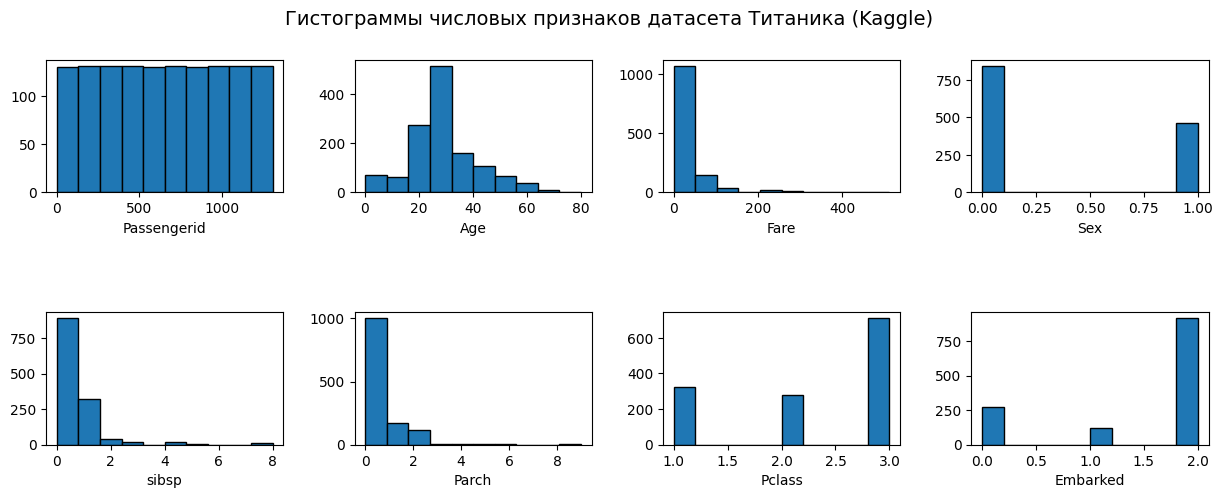

In [136]:
# Визуализация гистограмм числовых признаков (исключая нулевые столбцы)
# Выбираем все числовые колонки, кроме целевой
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# Убираем столбцы, которые полностью состоят из нулей (фиктивные переменные)
cols_to_plot = [col for col in numeric_cols if not (df[col] == 0).all()]


plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_plot):
    plt.subplot(2, 4, i+1)
    plt.hist(df[col].dropna(), edgecolor='black')
    plt.xlabel(col)
plt.subplots_adjust(hspace=0.9, wspace=0.3)
plt.suptitle('Гистограммы числовых признаков датасета Титаника (Kaggle)', fontsize=14)
plt.show()


=== Результаты моделей Наивного Байеса на тестовой выборке ===

Модель: GaussianNB
Accuracy: 0.8053
Confusion matrix:
[[171  23]
 [ 28  40]]
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       194
           1       0.63      0.59      0.61        68

    accuracy                           0.81       262
   macro avg       0.75      0.73      0.74       262
weighted avg       0.80      0.81      0.80       262



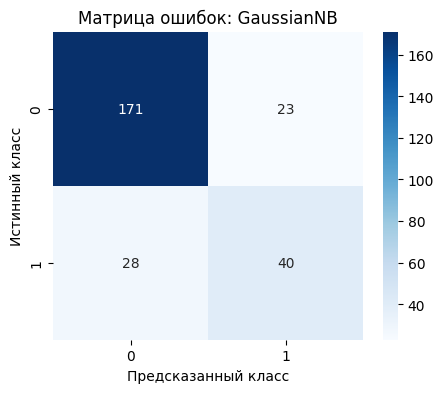

Модель: BernoulliNB
Accuracy: 0.7863
Confusion matrix:
[[177  17]
 [ 39  29]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       194
           1       0.63      0.43      0.51        68

    accuracy                           0.79       262
   macro avg       0.72      0.67      0.69       262
weighted avg       0.77      0.79      0.77       262



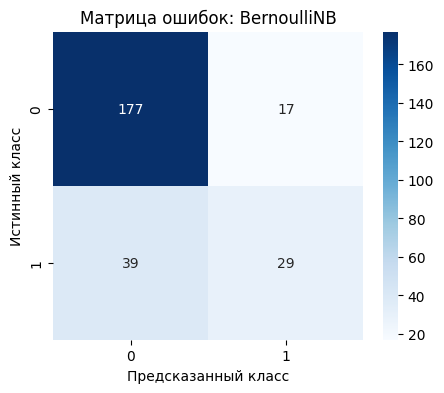

Модель: CategoricalNB
Accuracy: 0.6908
Confusion matrix:
[[145  49]
 [ 32  36]]
              precision    recall  f1-score   support

           0       0.82      0.75      0.78       194
           1       0.42      0.53      0.47        68

    accuracy                           0.69       262
   macro avg       0.62      0.64      0.63       262
weighted avg       0.72      0.69      0.70       262



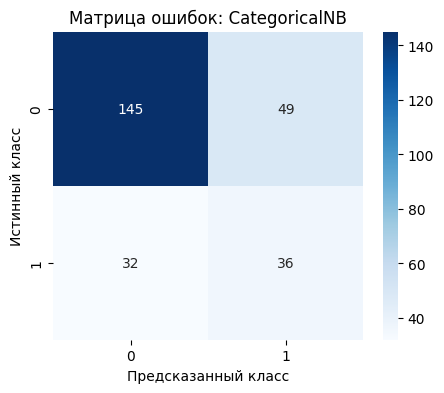

In [122]:
print("\n=== Результаты моделей Наивного Байеса на тестовой выборке ===\n")
for name, model, X_tr, X_te in models:
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    conf = confusion_matrix(y_test, y_pred)

    print(f"{'='*40}")
    print(f"Модель: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Confusion matrix:\n{conf}")
    print(classification_report(y_test, y_pred))

    # Визуализация матрицы ошибок
    plt.figure(figsize=(5, 4))
    sns.heatmap(conf, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Матрица ошибок: {name}')
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.show()

## Вывод по заданию 3 (Naive Bayes на Титанике Kaggle)

- **GaussianNB (80.5%)** – лучший результат. Модель хорошо справляется с непрерывными признаками (Age, Fare), так как их распределение близко к нормальному. Класс 0 (погибшие) распознаётся точнее (88% recall), класс 1 (выжившие) хуже из-за дисбаланса классов (выживших всего 272 из 1045).
- **BernoulliNB (78.6%)** – средний результат. Бинаризация по медиане упрощает данные, но теряет важные градации (например, возраст 10 и 60 лет становятся одинаковыми). Класс 1 распознаётся хуже всего (recall 43%).
- **CategoricalNB (69.1%)** – худший результат. Дискретизация непрерывных признаков в 5 бинов слишком грубая, стираются важные различия между объектами. Модель не подходит для данных с большим количеством числовых признаков.

**Рекомендация:** Для датасета с числовыми и бинарными признаками оптимален **GaussianNB**. BernoulliNB и CategoricalNB требуют более тщательной настройки параметров (порогов бинаризации и количества бинов), чтобы приблизиться к качеству GaussianNB.